# 实验：应用机器学习的建议
在本实验中，你将学习评估和改进机器学习模型的技术。

# 大纲
- [ 1 - 包 ](#1)
- [ 2 - 评估学习算法（多项式回归）](#2)
  - [ 2.1 划分数据集](#2.1)
  - [ 2.2 模型评估的误差计算，线性回归](#2.2)
    - [ 练习 1](#ex01)
  - [ 2.3 比较训练数据和测试数据上的性能](#2.3)
- [ 3 - 偏差和方差<img align="Right" src="./images/C2_W3_BiasVarianceDegree.png"  style=" width:500px; padding: 10px 20px ; "> ](#3)
  - [ 3.1 绘制训练集、交叉验证集、测试集](#3.1)
  - [ 3.2 寻找最优阶数](#3.2)
  - [ 3.3 调整正则化参数](#3.3)
  - [ 3.4 获取更多数据：增加训练集大小 (m)](#3.4)
- [ 4 - 评估学习算法（神经网络）](#4)
  - [ 4.1 数据集](#4.1)
  - [ 4.2 通过计算分类误差评估分类模型](#4.2)
    - [ 练习 2](#ex02)
- [ 5 - 模型复杂度](#5)
  - [ 练习 3](#ex03)
  - [ 5.1 简单模型](#5.1)
    - [ 练习 4](#ex04)
- [ 6 - 正则化](#6)
  - [ 练习 5](#ex05)
- [ 7 - 迭代寻找最优正则化值](#7)
  - [ 7.1 测试](#7.1)


_**注意：** 为防止自动评分器出错，不允许编辑或删除本notebook中的非评分单元格。请也不要添加任何新单元格。
**通过本作业后**，如果你想尝试任何非评分代码，可以按照本notebook底部的说明操作。_

<a name="1"></a>
## 1 - 包 

首先，运行下面的单元格导入本作业所需的所有包。
- [numpy](https://numpy.org/) 是Python科学计算的基础包。
- [matplotlib](http://matplotlib.org) 是Python中用于绘图的流行库。
- [scikitlearn](https://scikit-learn.org/stable/) 是数据挖掘的基础库。
- [tensorflow](https://www.tensorflow.org/) 是一个流行的机器学习平台。

In [2]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

from public_tests_a1 import * 

tf.keras.backend.set_floatx('float64')
from assigment_utils import *

tf.autograph.set_verbosity(0)

<a name="2"></a>
## 2 - 评估学习算法（多项式回归）

<img align="Right" src="./images/C2_W3_TrainingVsNew.png"  style=" width:350px; padding: 10px 20px ; "> 假设你创建了一个机器学习模型，发现它对训练数据*拟合*得很好。这样就完成了吗？并没有。创建模型的目标是能够对<span style="color:blue">*新* </span>样本进行预测。

如何在部署之前测试模型在新数据上的性能？
答案包含两个部分：
* 将原始数据集划分为"训练集"和"测试集"。
    * 使用训练数据来拟合模型的参数
    * 使用测试数据在*新*数据上评估模型
* 开发一个误差函数来评估你的模型。

<a name="2.1"></a>
### 2.1 划分数据集
课程建议将数据集的20-40%留作测试。让我们使用 `sklearn` 的函数 [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) 来执行划分。运行以下单元格后请检查数据的形状。

In [3]:
# 生成一些数据
X,y,x_ideal,y_ideal = gen_data(18, 2, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

# 使用sklearn例程拆分数据
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (18,) y.shape (18,)
X_train.shape (12,) y_train.shape (12,)
X_test.shape (6,) y_test.shape (6,)


#### 2.1.1 绘制训练集和测试集
你可以看到下方的训练数据点（红色）与模型未训练的数据点（测试集）混合在一起。这个特定的数据集是一个带有噪声的二次函数。"理想"曲线作为参考显示。

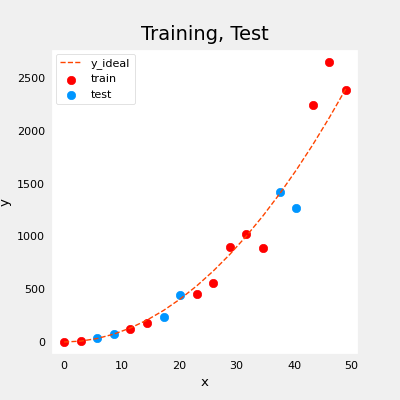

In [4]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

<a name="2.2"></a>
### 2.2 模型评估的误差计算，线性回归
在*评估*线性回归模型时，你需要计算预测值与目标值之间的均方误差。

$$ J_\text{test}(\mathbf{w},b) = 
            \frac{1}{2m_\text{test}}\sum_{i=0}^{m_\text{test}-1} ( f_{\mathbf{w},b}(\mathbf{x}^{(i)}_\text{test}) - y^{(i)}_\text{test} )^2 
            \tag{1}
$$

<a name="ex01"></a>
### 练习 1

下面，创建一个函数来计算线性回归模型在数据集上的误差。

In [5]:
# UNQ_C1
# GRADED CELL: eval_mse
def eval_mse(y, yhat):
    """ 
    计算数据集上的均方误差。
    参数:
      y    : (ndarray  Shape (m,) or (m,1))  每个样本的目标值
      yhat : (ndarray  Shape (m,) or (m,1))  每个样本的预测值
    返回:
      err: (scalar)             
    """
    m = len(y)
    err = 0.0
    for i in range(m):
    ### START CODE HERE ### 
        loss = (yhat[i] - y[i]) ** 2
        err += loss
    err = err / (2 * m)
    ### END CODE HERE ### 
    
    return(err)

In [6]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
eval_mse(y_hat, y_tmp)

# BEGIN UNIT TEST
test_eval_mse(eval_mse)   
# END UNIT TEST

 所有测试通过。


<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>

    
```python
def eval_mse(y, yhat):
    """ 
    Calculate the mean squared error on a data set.
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:
      err: (scalar)             
    """
    m = len(y)
    err = 0.0
    for i in range(m):
        err_i  = ( (yhat[i] - y[i])**2 ) 
        err   += err_i                                                                
    err = err / (2*m)                    
    return(err)
``` 

<a name="2.3"></a>
### 2.3 比较训练数据和测试数据上的性能
让我们构建一个高阶多项式模型来最小化训练误差。这将使用 `sklearn` 中的 linear_regression 函数。代码在导入的工具文件中，如果你想查看细节。步骤如下：
* 创建并拟合模型。（'fit' 是训练或运行梯度下降的另一种说法）。
* 计算训练数据上的误差。
* 计算测试数据上的误差。

In [7]:
# 在sklearn中创建模型，在训练数据上训练
degree = 10
lmodel = lin_model(degree)
lmodel.fit(X_train, y_train)

# 在训练数据上预测，计算训练误差
yhat = lmodel.predict(X_train)
err_train = lmodel.mse(y_train, yhat)

# 在测试数据上预测，计算误差
yhat = lmodel.predict(X_test)
err_test = lmodel.mse(y_test, yhat)

训练集上计算的误差远小于测试集上的误差。

In [8]:
print(f"training err {err_train:0.2f}, test err {err_test:0.2f}")

training err 58.01, test err 171215.01


下面的图表解释了原因。该模型对训练数据拟合得非常好。为此，它创建了一个复杂的函数。测试数据不是训练数据的一部分，模型在这些数据上的预测效果很差。
这个模型可以被描述为：1）过拟合，2）高方差，3）泛化能力差。

/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:88: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:88: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:88: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:88: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Pract

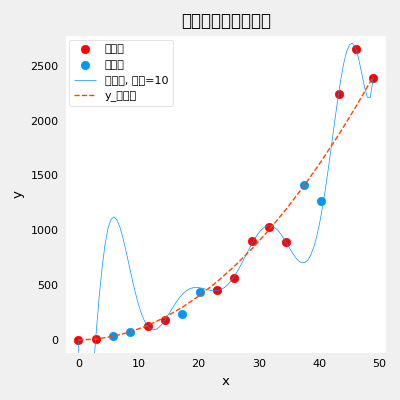

In [9]:
# 在数据范围内绘制预测值
x = np.linspace(0,int(X.max()),100)  # predict values for plot
y_pred = lmodel.predict(x).reshape(-1,1)

plt_train_test(X_train, y_train, X_test, y_test, x, y_pred, x_ideal, y_ideal, degree)

测试集误差表明该模型在新数据上表现不佳。如果你使用测试误差来指导模型改进，那么模型在测试数据上会表现良好……但测试数据是用来代表*新*数据的。
你需要另一组数据来测试新数据的性能。

课程中的建议是将数据分为三组。下面表格中显示的训练集、交叉验证集和测试集的分布是典型分布，但可以根据可用数据量进行调整。

| 数据             | 占比 | 描述 |
|------------------|:----------:|:---------|
| 训练集         | 60         | 用于在训练或拟合中调整模型参数 $w$ 和 $b$ 的数据 |
| 交叉验证集 | 20         | 用于调整其他模型参数的数据，如多项式阶数、正则化或神经网络架构。|
| 测试集             | 20         | 用于在调整后测试模型以评估新数据性能的数据 |


下面让我们生成三个数据集。我们将再次使用 `sklearn` 的 `train_test_split`，但会调用两次以获得三个划分：

In [10]:
# 生成数据
X,y, x_ideal,y_ideal = gen_data(40, 5, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

# 使用sklearn例程拆分数据
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.40, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.50, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (40,) y.shape (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (8,) y_cv.shape (8,)
X_test.shape (8,) y_test.shape (8,)


<a name="3"></a>
## 3 - 偏差和方差<img align="Right" src="./images/C2_W3_BiasVarianceDegree.png"  style=" width:500px; padding: 10px 20px ; "> 
 上面可以看出多项式模型的阶数太高了。如何选择一个好的值？如图所示，训练和交叉验证性能可以提供指导。通过尝试一系列阶数值，可以评估训练和交叉验证性能。当阶数变得太大时，交叉验证性能相对于训练性能会开始下降。让我们在示例中尝试一下。

<a name="3.1"></a>
### 3.1 绘制训练集、交叉验证集、测试集
你可以看到下方的训练数据点（红色）与模型未训练的数据点（测试集和交叉验证集）混合在一起。

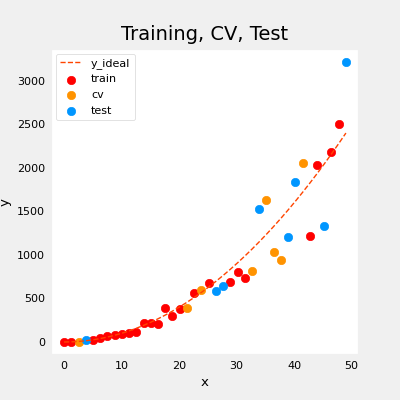

In [11]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(x_ideal, y_ideal, "--", color = "orangered", label="y_ideal", lw=1)
ax.set_title("Training, CV, Test",fontsize = 14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.scatter(X_train, y_train, color = "red",           label="train")
ax.scatter(X_cv, y_cv,       color = dlc["dlorange"], label="cv")
ax.scatter(X_test, y_test,   color = dlc["dlblue"],   label="test")
ax.legend(loc='upper left')
plt.show()

<a name="3.2"></a>
### 3.2 寻找最优阶数
在之前的实验中，你发现可以通过使用多项式来创建能够拟合复杂曲线的模型（参见课程1，第2周特征工程和多项式回归实验）。此外，你还演示了通过增加多项式的*阶数*，可以*制造*过拟合。（参见课程1，第3周，过拟合实验）。让我们在这里利用这些知识来测试区分过拟合和欠拟合的能力。

让我们反复训练模型，每次迭代增加多项式的阶数。这里，我们将使用 [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression) 的线性回归模型以提高速度和简洁性。

In [12]:
max_degree = 9
err_train = np.zeros(max_degree)    
err_cv = np.zeros(max_degree)      
x = np.linspace(0,int(X.max()),100)  
y_pred = np.zeros((100,max_degree))  #用于绘图的列

for degree in range(max_degree):
    lmodel = lin_model(degree+1)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[degree] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[degree] = lmodel.mse(y_cv, yhat)
    y_pred[:,degree] = lmodel.predict(x)
    
optimal_degree = np.argmin(err_cv)+1

<font size="4">让我们绘制结果：</font>

/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:124: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:124: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:124: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:124: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/P

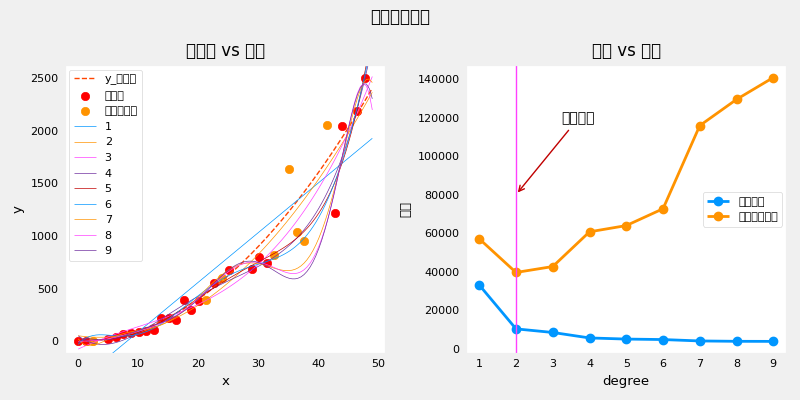

In [13]:
plt.close("all")
plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal, 
                   err_train, err_cv, optimal_degree, max_degree)

上图表明，将数据分为两组（模型训练过的数据和模型未训练过的数据）可以用来判断模型是欠拟合还是过拟合。在我们的示例中，通过增加使用的多项式阶数，我们创建了从欠拟合到过拟合的各种模型。
- 在左图中，实线代表这些模型的预测。阶数为1的多项式模型产生一条与很少数据点相交的直线，而最大阶数则非常紧密地贴合每个数据点。
- 在右图中：
    - 训练数据上的误差（蓝色）如预期那样随着模型复杂度的增加而减小
    - 交叉验证数据的误差最初随着模型开始适应数据而减小，但随后随着模型开始在训练数据上过拟合（无法*泛化*）而增加。
    
值得注意的是，这些示例中的曲线不如课堂上画的那么平滑。显然，分配给每组的特定数据点会显著改变你的结果。重要的是总体趋势。

<a name="3.3"></a>
### 3.3 调整正则化参数
在之前的实验中，你已经使用*正则化*来减少过拟合。与阶数类似，可以使用相同的方法来调整正则化参数 lambda ($\lambda$)。

让我们从一个高阶多项式开始，通过改变正则化参数来演示这一点。

In [14]:
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)    
err_cv = np.zeros(num_steps)       
x = np.linspace(0,int(X.max()),100) 
y_pred = np.zeros((100,num_steps))  #用于绘图的列

for i in range(num_steps):
    lambda_= lambda_range[i]
    lmodel = lin_model(degree, regularization=True, lambda_=lambda_)
    lmodel.fit(X_train, y_train)
    yhat = lmodel.predict(X_train)
    err_train[i] = lmodel.mse(y_train, yhat)
    yhat = lmodel.predict(X_cv)
    err_cv[i] = lmodel.mse(y_cv, yhat)
    y_pred[:,i] = lmodel.predict(x)
    
optimal_reg_idx = np.argmin(err_cv) 

/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:162: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:162: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:162: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:162: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/P

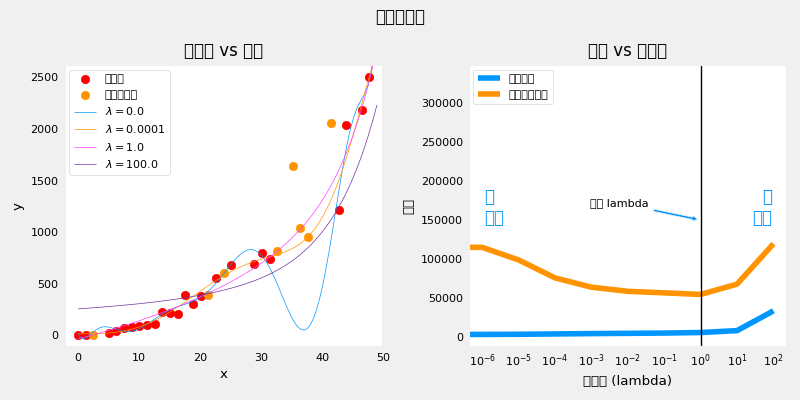

In [15]:
plt.close("all")
plt_tune_regularization(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range)

上图显示，随着正则化的增加，模型从高方差（过拟合）模型转变为高偏差（欠拟合）模型。右图中的垂直线显示了 lambda 的最优值。在这个示例中，多项式阶数设置为10。

<a name="3.4"></a>
### 3.4 获取更多数据：增加训练集大小 (m)
当模型过拟合（高方差）时，收集更多数据可以提高性能。让我们在这里尝试一下。

/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:219: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:219: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:219: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/Practice Labs/assigment_utils.py:219: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/andrewNG/Course 2 - Advanced Learning Algorithms/Course 2 - Week 3/P

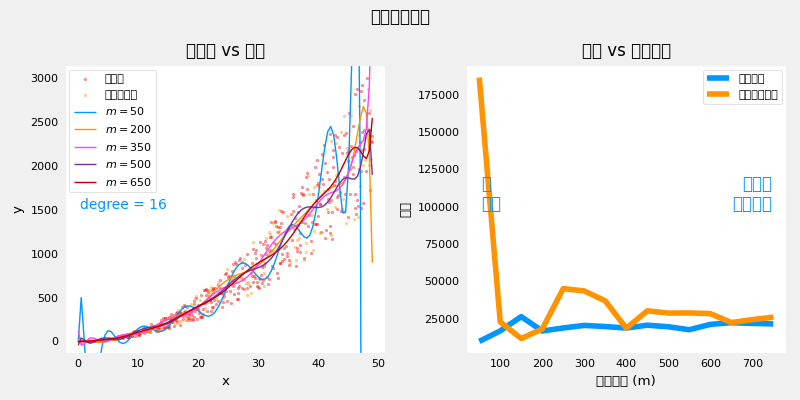

In [16]:
X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range,degree = tune_m()
plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree)

上图显示，当模型具有高方差且过拟合时，添加更多样本可以提高性能。注意左图中的曲线。$m$ 值最高的最终曲线是一条位于数据中心的平滑曲线。在右图中，随着样本数量的增加，训练集和交叉验证集的性能趋向于相似的值。注意曲线不如课堂上看到的那么平滑。这是预期的。趋势仍然很明确：更多数据改善泛化能力。

> 注意，当模型具有高偏差（欠拟合）时，添加更多样本并不能改善性能。


<a name="4"></a>
## 4 - 评估学习算法（神经网络）
上面，你调整了多项式回归模型的各个方面。在这里，你将使用神经网络模型。让我们从创建一个分类数据集开始。

<a name="4.1"></a>
### 4.1 数据集
运行下面的单元格生成数据集，并将其划分为训练集、交叉验证集（CV）和测试集。在这个示例中，我们增加了交叉验证数据点的百分比以作强调。

In [17]:
# 生成并拆分数据集
X, y, centers, classes, std = gen_blobs()

# 拆分数据。大量交叉验证数据用于演示
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.20, random_state=1)
print("X_train.shape:", X_train.shape, "X_cv.shape:", X_cv.shape, "X_test.shape:", X_test.shape)

X_train.shape: (400, 2) X_cv.shape: (320, 2) X_test.shape: (80, 2)


/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 20132 (\N{CJ

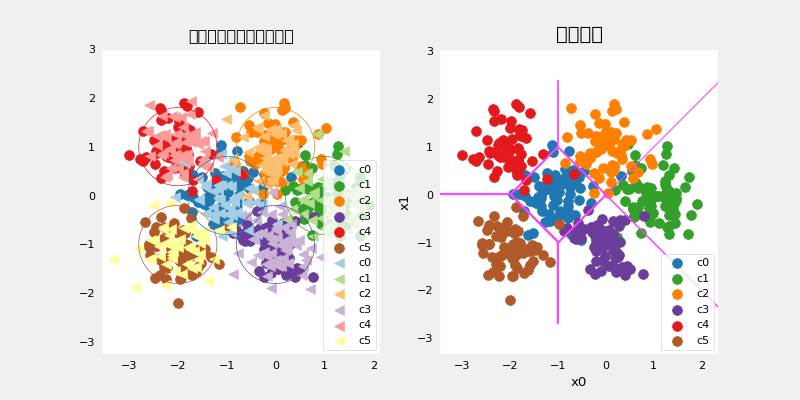

In [18]:
plt_train_eq_dist(X_train, y_train,classes, X_cv, y_cv, centers, std)

上面，你可以看到左边的数据。有六个按颜色区分的聚类。显示了训练点（圆点）和交叉验证点（三角形）。有趣的是那些落在模糊位置的点，两个聚类都可能将它们视为成员。你期望神经网络模型怎么做？过拟合的例子是什么？欠拟合呢？
右边是一个"理想"模型的示例，或者说是知道数据来源时可能创建的模型。这些线代表"等距"边界，其中中心点之间的距离相等。值得注意的是，这个模型会"错误分类"大约8%的总数据集。

<a name="4.2"></a>
### 4.2 通过计算分类误差评估分类模型
这里使用的分类模型评估函数就是错误预测的比例：
$$ J_{cv} =\frac{1}{m}\sum_{i=0}^{m-1} 
\begin{cases}
    1, & \text{if $\hat{y}^{(i)} \neq y^{(i)}$}\\
    0, & \text{otherwise}
\end{cases}
$$

<a name="ex02"></a>
### 练习 2

下面，完成计算分类误差的例程。注意，在本实验中，目标值是类别的索引，而不是 [one-hot 编码](https://en.wikipedia.org/wiki/One-hot)。

In [19]:
# UNQ_C2
# GRADED CELL: eval_cat_err
def eval_cat_err(y, yhat):
    """ 
    计算分类误差
    参数:
      y    : (ndarray  Shape (m,) or (m,1))  每个样本的目标值
      yhat : (ndarray  Shape (m,) or (m,1))  每个样本的预测值
    返回:
      cerr: (scalar)             
    """
    m = len(y)
    incorrect = 0
    for i in range(m):
    ### START CODE HERE ### 
       if yhat[i] != y[i]:
            incorrect += 1
    cerr = incorrect / m
    ### END CODE HERE ### 
    
    return(cerr)

In [20]:
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333" )
y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250" )

# BEGIN UNIT TEST  
test_eval_cat_err(eval_cat_err)
# END UNIT TEST

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250
 所有测试通过。


<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
```python
def eval_cat_err(y, yhat):
    """ 
    Calculate the categorization error
    Args:
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example
    Returns:|
      cerr: (scalar)             
    """
    m = len(y)
    incorrect = 0
    for i in range(m):
        if yhat[i] != y[i]:    # @REPLACE
            incorrect += 1     # @REPLACE
    cerr = incorrect/m         # @REPLACE
    return(cerr)                                    
``` 

<a name="5"></a>
## 5 - 模型复杂度
下面，你将构建两个模型。一个复杂模型和一个简单模型。你将评估这些模型以确定它们是否可能过拟合或欠拟合。

###  5.1 复杂模型

<a name="ex03"></a>
### 练习 3
下面，构建一个三层模型：
* Dense层，120个单元，relu激活
* Dense层，40个单元，relu激活
* Dense层，6个单元，线性激活（不是softmax）
使用以下配置编译：
* 使用 `SparseCategoricalCrossentropy` 作为损失函数，记得使用 `from_logits=True`
* Adam优化器，学习率为0.01。

In [21]:
# UNQ_C3
# GRADED CELL: model
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

tf.random.set_seed(1234)
model = Sequential(
    [
        ### START CODE HERE ### 
        Dense(units = 120, activation = "relu", name = "L1"),
        Dense(units = 40, activation = "relu", name = "L2"),
        Dense(units = 6, activation = "linear", name = "L3"),
        ### END CODE HERE ### 

    ], name="Complex"
)
model.compile(
    ### START CODE HERE ### 
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),
    ### END CODE HERE ### 
)

W0000 00:00:1785857066.597218  184611 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [22]:
# BEGIN UNIT TEST
model.fit(
    X_train, y_train,
    epochs=1000
)
# END UNIT TEST

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1102  
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4028 
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3164 
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2649 
Epoch 5/1000


W0000 00:00:1785857067.106652  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.106751  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.106776  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.106821  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.106843  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.122903  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.123009  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.123033  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.123078  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857067.123111  184611 util.cc:163] Not handling type DT_DOUBLE


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2433 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2355 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2299 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2246 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2225 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2194 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2177 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2169 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2132 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2128 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2119 
Epoch 16/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2103 
Epoch 17/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2081 
Epoch 18/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2078 
Epoch 19/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [23]:
# BEGIN UNIT TEST
model.summary()

model_test(model, classes, X_train.shape[1]) 
# END UNIT TEST

Model: "Complex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

所有测试通过！


<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
摘要应该与下面的内容匹配（层实例名称可能会递增）
```
Model: "Complex"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 120)               360       
_________________________________________________________________
L2 (Dense)                   (None, 40)                4840      
_________________________________________________________________
L3 (Dense)                   (None, 6)                 246       
=================================================================
Total params: 5,446
Trainable params: 5,446
Non-trainable params: 0
_________________________________________________________________
```
  <details>
  <summary><font size="3" color="darkgreen"><b>点击查看更多提示</b></font></summary>
  
```python
tf.random.set_seed(1234)
model = Sequential(
    [
        Dense(120, activation = 'relu', name = "L1"),      
        Dense(40, activation = 'relu', name = "L2"),         
        Dense(classes, activation = 'linear', name = "L3")  
    ], name="Complex"
)
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),          
    optimizer=tf.keras.optimizers.Adam(0.01),   
)

model.fit(
    X_train,y_train,
    epochs=1000
)                                  
``` 

 319/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step

W0000 00:00:1785857108.934575  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.934756  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.934782  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.934886  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.934907  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.936496  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.936642  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.936683  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.936804  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857108.936840  184611 util.cc:163] Not handling type DT_DOUBLE


1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1s 497us/step


W0000 00:00:1785857109.463240  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.463385  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.463409  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.463508  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.463528  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.465135  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.465279  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.465315  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.465419  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857109.465451  184611 util.cc:163] Not handling type DT_DOUBLE


1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step


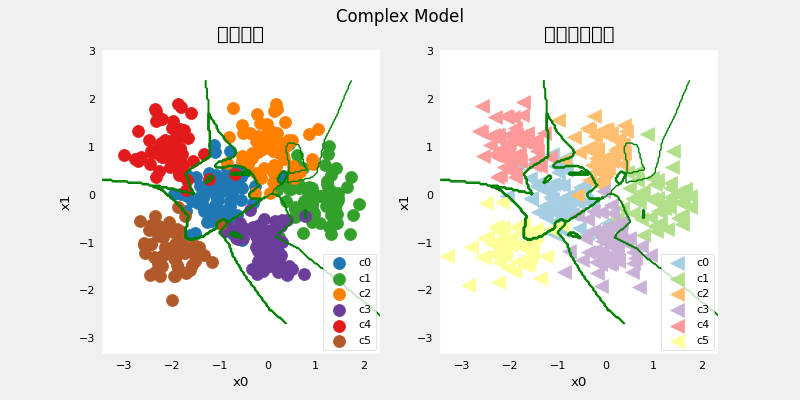

In [24]:
#创建一个模型供绘图例程调用
model_predict = lambda Xl: np.argmax(tf.nn.softmax(model.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict,X_train,y_train, classes, X_cv, y_cv, suptitle="Complex Model")

这个模型非常努力地捕捉每个类别的离群值。结果，它对一些交叉验证数据进行了错误分类。让我们计算分类误差。

In [25]:
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
categorization error, training, complex model: 0.007
categorization error, cv,       complex model: 0.122


<a name="5.1"></a>
### 5.1 简单模型
现在，让我们尝试一个简单模型

<a name="ex04"></a>
### 练习 4

下面，构建一个两层模型：
* Dense层，6个单元，relu激活
* Dense层，6个单元，线性激活
使用以下配置编译：
* 使用 `SparseCategoricalCrossentropy` 作为损失函数，记得使用 `from_logits=True`
* Adam优化器，学习率为0.01。

In [26]:
# UNQ_C4
# GRADED CELL: model_s

tf.random.set_seed(1234)
model_s = Sequential(
    [
        ### START CODE HERE ### 
        Dense(units = 6, activation = "relu", name = "L1"),
        Dense(units = 6, activation = "linear", name = "L2"),
        ### END CODE HERE ### 
    ], name = "Simple"
)
model_s.compile(
    ### START CODE HERE ### 
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
    ### START CODE HERE ### 
)


In [27]:
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

# BEGIN UNIT TEST
model_s.fit(
    X_train,y_train,
    epochs=1000
)
# END UNIT TEST

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8881  
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6124 
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4554 
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3113 
Epoch 5/1000
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1801

W0000 00:00:1785857111.052421  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857111.052551  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857111.052577  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857111.064517  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857111.064638  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857111.064662  184611 util.cc:163] Not handling type DT_DOUBLE


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1564 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9976 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8516 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7287 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6288 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5482 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4850 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4370 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4003 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3717 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3487 
Epoch 16/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3298 
Epoch 17/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3141 
Epoch 18/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3010 
Epoch 19/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [28]:
# BEGIN UNIT TEST
model_s.summary()

model_s_test(model_s, classes, X_train.shape[1])
# END UNIT TEST

Model: "Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182 (1.42 KB)

 Trainable params: 60 (480.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122 (976.00 B)

所有测试通过！


<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
摘要应该与下面的内容匹配（层实例名称可能会递增）
```
Model: "Simple"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 6)                 18        
_________________________________________________________________
L2 (Dense)                   (None, 6)                 42        
=================================================================
Total params: 60
Trainable params: 60
Non-trainable params: 0
_________________________________________________________________
```
  <details>
  <summary><font size="3" color="darkgreen"><b>点击查看更多提示</b></font></summary>
  
```python
tf.random.set_seed(1234)
model_s = Sequential(
    [
        Dense(6, activation = 'relu', name="L1"),            # @REPLACE
        Dense(classes, activation = 'linear', name="L2")     # @REPLACE
    ], name = "Simple"
)
model_s.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),     # @REPLACE
    optimizer=tf.keras.optimizers.Adam(0.01),     # @REPLACE
)

model_s.fit(
    X_train,y_train,
    epochs=1000
)                                   
``` 

 302/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step

W0000 00:00:1785857150.888975  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857150.889150  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857150.889175  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857150.890562  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857150.890717  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857150.890755  184611 util.cc:163] Not handling type DT_DOUBLE


1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1s 517us/step


W0000 00:00:1785857151.438049  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857151.438191  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857151.438213  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857151.439502  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857151.439648  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857151.439686  184611 util.cc:163] Not handling type DT_DOUBLE


1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1s 477us/step


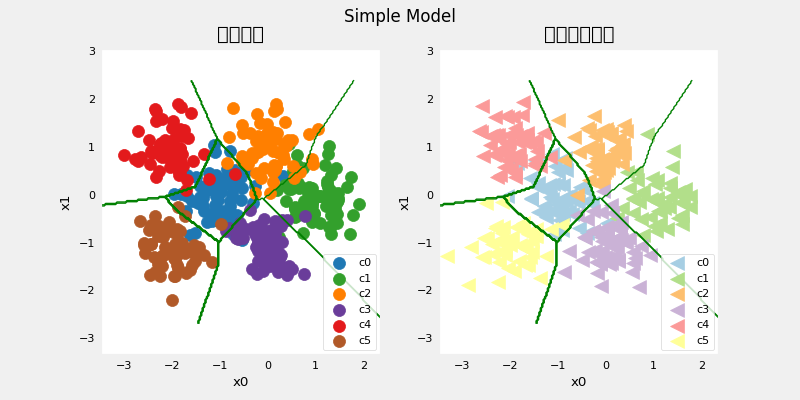

In [29]:
#创建一个模型供绘图例程调用
model_predict_s = lambda Xl: np.argmax(tf.nn.softmax(model_s.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict_s,X_train,y_train, classes, X_cv, y_cv, suptitle="Simple Model")

这个简单模型表现得相当不错。让我们计算分类误差。

In [30]:
training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f"categorization error, training, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
categorization error, training, simple model, 0.077, complex model: 0.007
categorization error, cv,       simple model, 0.062, complex model: 0.122


我们的简单模型在训练数据上的分类误差略高，但在交叉验证数据上的表现比更复杂的模型更好。

<a name="6"></a>
## 6 - 正则化
与多项式回归的情况类似，可以应用正则化来调节更复杂模型的影响。让我们在下面尝试一下。

<a name="ex05"></a>
### 练习 5

重新构建你的复杂模型，但这次包含正则化。
下面，构建一个三层模型：
* Dense层，120个单元，relu激活，`kernel_regularizer=tf.keras.regularizers.l2(0.1)`
* Dense层，40个单元，relu激活，`kernel_regularizer=tf.keras.regularizers.l2(0.1)`
* Dense层，6个单元，线性激活
使用以下配置编译：
* 使用 `SparseCategoricalCrossentropy` 作为损失函数，记得使用 `from_logits=True`
* Adam优化器，学习率为0.01。

In [31]:
# UNQ_C5
# GRADED CELL: model_r

tf.random.set_seed(1234)
model_r = Sequential(
    [
        ### START CODE HERE ### 
        Dense(units = 120, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.1), name = "L1"),
        Dense(units = 40, activation = "relu", kernel_regularizer=tf.keras.regularizers.l2(0.1), name = "L2"),
        Dense(units = 6, activation = "linear", name = "L3"),
        ### START CODE HERE ### 
    ], name= None
)
model_r.compile(
    ### START CODE HERE ### 
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01),
    ### START CODE HERE ### 
)


In [32]:
# BEGIN UNIT TEST
model_r.fit(
    X_train, y_train,
    epochs=1000
)
# END UNIT TEST

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.4355  
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6045 
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2862 
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0814 
Epoch 5/1000


W0000 00:00:1785857153.247729  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.247843  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.247987  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.248098  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.248127  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.266985  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.267078  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.267105  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.267342  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857153.267379  184611 util.cc:163] Not handling type DT_DOUBLE


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9936 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9499 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9095 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8715 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8343 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8044 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7839 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7684 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7537 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7383 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7238 
Epoch 16/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7107 
Epoch 17/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6992 
Epoch 18/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6888 
Epoch 19/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [33]:
# BEGIN UNIT TEST
model_r.summary()

model_r_test(model_r, classes, X_train.shape[1]) 
# END UNIT TEST

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (127.66 KB)

 Trainable params: 5,446 (42.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (85.11 KB)

ddd
所有测试通过！


<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
摘要应该与下面的内容匹配（层实例名称可能会递增）
```
Model: "ComplexRegularized"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 120)               360       
_________________________________________________________________
L2 (Dense)                   (None, 40)                4840      
_________________________________________________________________
L3 (Dense)                   (None, 6)                 246       
=================================================================
Total params: 5,446
Trainable params: 5,446
Non-trainable params: 0
_________________________________________________________________
```
  <details>
  <summary><font size="3" color="darkgreen"><b>点击查看更多提示</b></font></summary>
  
```python
tf.random.set_seed(1234)
model_r = Sequential(
    [
        Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(0.1), name="L1"), 
        Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(0.1), name="L2"),  
        Dense(classes, activation = 'linear', name="L3")  
    ], name="ComplexRegularized"
)
model_r.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), 
    optimizer=tf.keras.optimizers.Adam(0.01),                             
)

model_r.fit(
    X_train,y_train,
    epochs=1000
)                                   
``` 

 304/1082 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step

W0000 00:00:1785857194.513854  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.514000  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.514023  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.514123  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.514156  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.515679  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.515824  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.515859  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.515960  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857194.515992  184611 util.cc:163] Not handling type DT_DOUBLE


1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1s 508us/step


W0000 00:00:1785857195.053363  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.053501  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.053523  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.053622  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.053642  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.055172  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.055319  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.055355  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.055459  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857195.055493  184611 util.cc:163] Not handling type DT_DOUBLE


1082/1082 ━━━━━━━━━━━━━━━━━━━━ 1s 496us/step


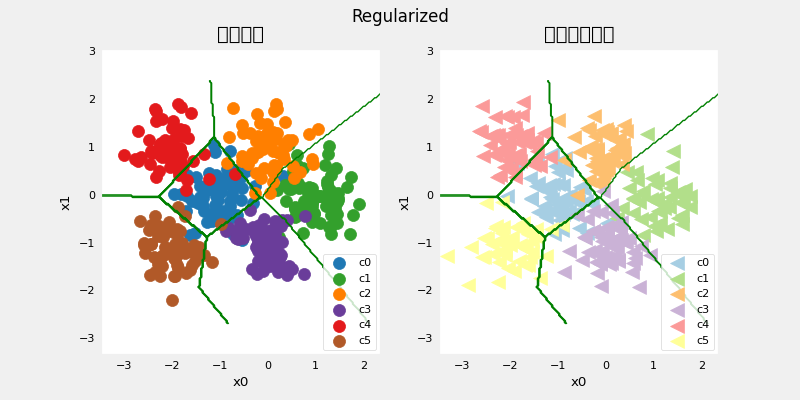

In [34]:
#创建一个模型供绘图例程调用
model_predict_r = lambda Xl: np.argmax(tf.nn.softmax(model_r.predict(Xl)).numpy(),axis=1)
 
plt_nn(model_predict_r, X_train,y_train, classes, X_cv, y_cv, suptitle="Regularized")

结果看起来与"理想"模型非常相似。让我们检查分类误差。

In [35]:
training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
test_cerr_reg = eval_cat_err(y_test, model_predict_r(X_test))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
categorization error, training, regularized: 0.085, simple model, 0.077, complex model: 0.007
categorization error, cv,       regularized: 0.075, simple model, 0.062, complex model: 0.122


简单模型在训练集上比正则化模型稍好，但在交叉验证集上表现较差。

<a name="7"></a>
## 7 - 迭代寻找最优正则化值
与线性回归中一样，你可以尝试许多正则化值。这段代码需要几分钟才能运行。如果你有时间，可以运行它并检查结果。如果没有，你已经完成了作业的评分部分！

In [36]:
tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models=[None] * len(lambdas)

for i in range(len(lambdas)):
    lambda_ = lambdas[i]
    models[i] =  Sequential(
        [
            Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(classes, activation = 'linear')
        ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.01),
    )

    models[i].fit(
        X_train,y_train,
        epochs=1000
    )
    print(f"Finished lambda = {lambda_}")


Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0659  
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4017 
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3688 
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2813 
Epoch 5/1000
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1949

W0000 00:00:1785857196.960059  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.960156  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.960182  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.960226  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.960247  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.977504  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.977609  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.977637  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.977830  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857196.977868  184611 util.cc:163] Not handling type DT_DOUBLE


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2483 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2516 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2375 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2266 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2208 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2218 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2175 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2180 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2126 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2154 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2104 
Epoch 16/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2098 
Epoch 17/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2075 
Epoch 18/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2065 
Epoch 19/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

W0000 00:00:1785857237.846779  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.846885  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.846921  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.846970  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.846990  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.863916  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.864011  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.864035  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.864218  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857237.864252  184611 util.cc:163] Not handling type DT_DOUBLE


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3235 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3183 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3107 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3020 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2904 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2856 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2812 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2791 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2766 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2736 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2700 
Epoch 16/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2711 
Epoch 17/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2685 
Epoch 18/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2658 
Epoch 19/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0101 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9513 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8966 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8507 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8160 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7941 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7757 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7573 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7428 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7291 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7171 
Epoch 16/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7064 
Epoch 17/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6942 
Epoch 18/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6824 
Epoch 19/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

W0000 00:00:1785857410.674576  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.674787  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.674854  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.674951  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.674994  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.712352  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.712537  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.712586  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.712964  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857410.713032  184611 util.cc:163] Not handling type DT_DOUBLE


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.0499 
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7536 
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4044 
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2668 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1918 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1385 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0882 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0419 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0049 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9773 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9553 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9359 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9175 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9000 
Epoch 16/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - 

W0000 00:00:1785857492.338771  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.338921  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.338959  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.339020  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.339049  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.360735  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.360854  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.360881  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.361151  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857492.361202  184611 util.cc:163] Not handling type DT_DOUBLE


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0042 
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6510 
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5439 
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4853 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4464 
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4173 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3919 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3706 
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3518 
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3359 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3224 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3098 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2986 
Epoch 16/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2884 
Epoch 17/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step -

/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 212

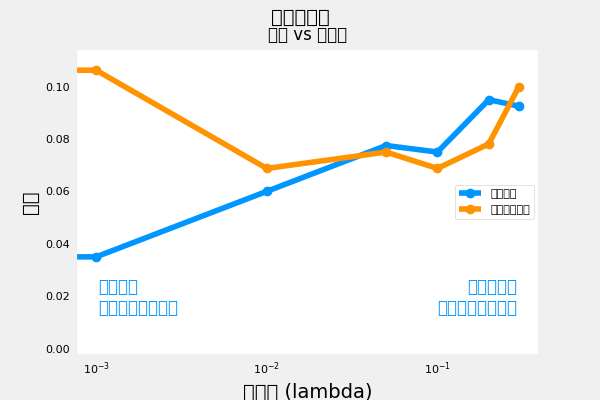

In [37]:
plot_iterate(lambdas, models, X_train, y_train, X_cv, y_cv)

随着正则化的增加，模型在训练集和交叉验证集上的性能趋于一致。对于这个数据集和模型，lambda > 0.01 似乎是一个合理的选择。

<a name="7.1"></a>
### 7.1 测试
让我们在测试集上尝试优化后的模型，并将它们与"理想"性能进行比较。

  54/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step

W0000 00:00:1785857561.619057  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857561.619263  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857561.619300  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857561.621332  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857561.621545  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857561.621603  184611 util.cc:163] Not handling type DT_DOUBLE


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step
 173/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step

W0000 00:00:1785857562.702190  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.702401  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.702436  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.702581  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.702611  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.704589  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.704746  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.704787  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.704932  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857562.704966  184611 util.cc:163] Not handling type DT_DOUBLE


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


W0000 00:00:1785857564.287191  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.287435  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.287474  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.290907  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.291171  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.291238  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.379996  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.380210  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.380259  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.380418  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.380470  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.383644  184611 util.cc:163] Not handling type DT_DOUBLE
W0000 00:00:1785857564.383902  184611 util.cc:163] N

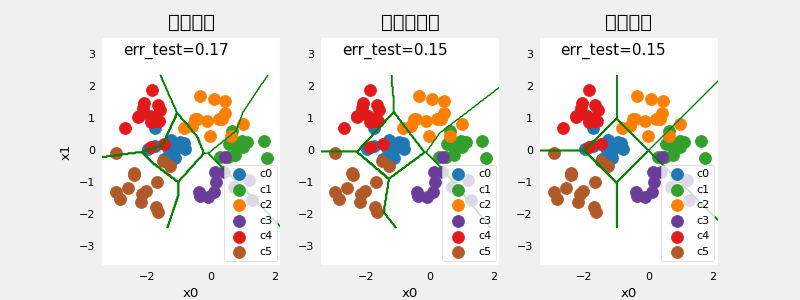

In [38]:
plt_compare(X_test,y_test, classes, model_predict_s, model_predict_r, centers)

我们的测试集较小，似乎有许多离群值，因此分类误差较高。然而，我们优化后的模型的性能与理想性能相当。

## 恭喜！
你已经熟悉了评估机器学习模型时的重要工具。即：
* 将数据划分为训练集和未训练集可以让你区分欠拟合和过拟合
* 创建三个数据集（训练集、交叉验证集和测试集）可以让你
    * 使用训练集训练参数 $W,B$
    * 使用交叉验证集调整模型参数，如复杂度、正则化和样本数量
    * 使用测试集评估你的"真实世界"性能
* 比较训练集与交叉验证集的性能可以提供关于模型过拟合（高方差）或欠拟合（高偏差）倾向的洞察

<details>
  <summary><font size="2" color="darkgreen"><b>如果你想尝试任何非评分代码，请点击此处。</b></font></summary>
    <p><i><b>重要提示：请仅在通过作业后再执行此操作，以避免自动评分器出现问题。</b></i>
    <ol>
        <li> 在notebook菜单中，点击"View" > "Cell Toolbar" > "Edit Metadata"</li>
        <li> 点击你想要锁定/解锁的代码单元格旁边的"Edit Metadata"按钮</li>
        <li> 将"editable"属性值设置为：
            <ul>
                <li> "true" 如果你想解锁它 </li>
                <li> "false" 如果你想锁定它 </li>
            </ul>
        </li>
        <li> 在notebook菜单中，点击"View" > "Cell Toolbar" > "None" </li>
    </ol>
    <p> 这是关于如何执行上述步骤的简短演示：
        <br>
        <img src="https://drive.google.com/uc?export=view&id=14Xy_Mb17CZVgzVAgq7NCjMVBvSae3xO1" align="center" alt="unlock_cells.gif">
</details>